Aknur Mansurkhan

Есептер апта 17

1️⃣ Теоретические задачи

Эти задачи помогают понять, как VAE работает на уровне концепций и формул.

Энкодер и декодер


* Объясните своими словами, чем VAE отличается от обычного автоэнкодера.


* Почему в VAE вместо прямого кодирования в z мы используем распределение q(z|x)?






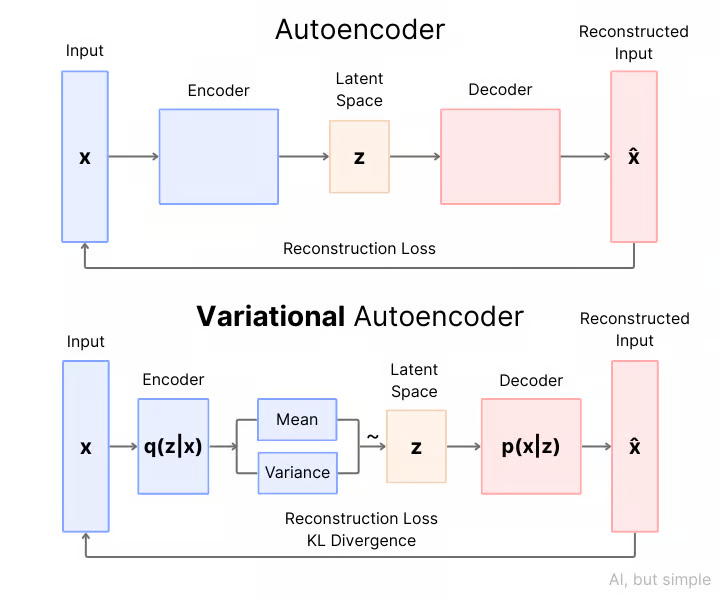

Латентті кеңістік — бұл деректердің "мәні" сақталатын виртуалды карта

Энкодер — суретті осы картадағы нүктеге айналдырады.

Декодер — осы картадағы нүктені қайтадан суретке айналдырады.

1. Латентті кеңістік (Жасырын қабат)

Autoencoder (AE): Мәліметті нақты бір нүктеге (векторға) айналдырады. Мысалы, мысықтың суретін (2.5,−1.2) деген нақты координатаға теңейді. Ол тек "есте сақтауға" тырысады.

VAE: Мәліметті ықтималдық үлестіріміне (бұлт тәрізді аймаққа) айналдырады. Ол нақты нүктені емес, математикалық орташа мән мен ауытқуды (μ және σ) есептейді. Ол "бұл мысық мына бір аймақтың маңайында орналасқан" дейді.

2. Мақсаты: Қысу ма, әлде Жаңа дүние жасау ма?

Autoencoder: Негізінен мәліметтің көлемін азайту (compression) немесе суреттегі шуды тазарту (denoising) үшін қолданылады. Егер сіз оның кеңістігінен кездейсоқ нүкте алсаңыз, ол түсініксіз, мағынасыз сурет шығаруы мүмкін.

VAE: Бұл генеративті модель. Оның мақсаты — жаңа деректер ойлап табу. Латентті кеңістігі жинақы әрі жүйелі болғандықтан, кез келген нүктені таңдасаңыз да, ол бұрын болмаған, бірақ шынайыға ұқсайтын жаңа сурет (мысалы, жаңа адамның түрі) жасап бере алады.

3. Қателік функциясы (Loss Function)

Autoencoder: Тек Reconstruction Loss (қайта қалпына келтіру қателігі) қолданылады. "Шыққан сурет кірген суретке қаншалықты ұқсайды?" деген сұраққа жауап береді.

VAE: Екі түрлі қателікті есептейді:

Reconstruction Loss (ұқсастық).
KL Divergence: Бұл математикалық жазалау жүйесі. Ол латентті кеңістіктің шашырап кетпеуін және барлық мәліметтердің белгілі бір ретпен орналасуын қадағалайды.

___________________________________________

Неге (q(z∣x)) ?

Мәселе: Сіз екі суреттің (мысалы, "1" және "7" цифрлары) арасындағы нүктені алып, оны декодерге берсеңіз, ол түсініксіз шимай шығаруы мүмкін

 Себебі ол аралықтағы нүктелермен жұмыс істеп үйренбеген.

Шешімі (q(z∣x)): Біз нүктені емес, белгілі бір "аймақты" (distribution) кодтаймыз. Бұл модельді латентті кеңістіктің барлық бөлігін мағыналы түрде толтыруға мәжбүрлейді.

Если кодировать в точку:

* модель просто запоминает данные (overfitting)

Если кодировать распределение:

* каждый объект представлен облаком точек

* появляется регуляризация

* модель учится обобщать

Интуиция:
Один образ → не точка, а “область возможных представлений”.

Это делает генерацию возможной.

___________________________________________

2.Распределение латентного пространства


Допустим, латентное пространство двумерное. **Нарисуйте, как распределение z должно выглядеть для нормального распределения N(0,1) и что происходит, если энкодер сильно отклоняется от этого распределения.**




Если latent space = 2D:

Идеально:

*   точки образуют круг/облако вокруг (0,0)
* плотность максимальна в центре
* постепенно уменьшается к краям

Если энкодер отклоняется:
* появляются «дыры»
* появляются разорванные кластеры
* sampling начинает давать мусор

То есть:
Хорошее пространство → гладкое облако

Плохое → острова и пустоты

________________________


**Объясните роль KL-дивергенции в VAE**

Почему мы минимизируем её между q(z|x) и p(z)?


KL(q(z|x) || p(z)) измеряет:

* Насколько распределение encoder отличается от нормального N(0,1)

Мы хотим:

**q(z|x) ≈ N(0,1)**

Почему?

Чтобы можно было:

* брать случайную точку из N(0,1)
* декодировать её в изображение

Без этого генерация невозможна

KL = регуляризатор латентного пространства



---
**Функция потерь**


**Разделите ELBO (Evidence Lower Bound) на две части и объясните каждую:**

* Reconstruction loss
* KL-divergence loss

1. **Reconstruction loss**

Отвечает за:Насколько хорошо восстановили изображение

обычно: BCE или MSE

Если только этот loss:

модель станет обычным автоэнкодером.

2. **KL-divergence loss**

Отвечает за: Красивое и гладкое латентное пространство.

Баланс:

Reconstruction → точность

KL → генеративность

❗ **Что если убрать KL полностью**

Получим обычный AE:

Проблемы:


*   латентное пространство разорвано
*   Генерация исчезает



---

**2 Практика — реализация VAE (MNIST)**

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from torch.utils.data import DataLoader, Subset


In [20]:
transform = transforms.ToTensor()

train_data = torchvision.datasets.MNIST(root="./data", train=True,
                                        transform=transform, download=True)

test_data = torchvision.datasets.MNIST(root="./data", train=False,
                                       transform=transform, download=True)

# keep only digits 0-8 for training (normal data)
normal_idx = [i for i,(x,y) in enumerate(train_data) if y != 9]
train_normal = Subset(train_data, normal_idx)

train_loader = DataLoader(train_normal, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128, shuffle=False)


3️⃣ VAE model (2D latent space)

In [21]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU()
        )

        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + eps * torch.exp(0.5 * logvar)

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar


4️⃣ Loss (ELBO)

In [22]:
def vae_loss(x_hat, x, mu, logvar, beta=1):
    recon = F.binary_cross_entropy(x_hat, x.view(-1,784), reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta*kl


5️⃣ Train VAE on NORMAL DATA

In [23]:
model = VAE()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    total_loss = 0
    for x,_ in train_loader:
        x_hat, mu, logvar = model(x)
        loss = vae_loss(x_hat, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print("Epoch", epoch, "Loss:", total_loss)


Epoch 0 Loss: 10503959.511230469
Epoch 1 Loss: 9188823.186523438
Epoch 2 Loss: 8970536.872070312
Epoch 3 Loss: 8859941.24609375
Epoch 4 Loss: 8777692.620117188
Epoch 5 Loss: 8709332.627929688
Epoch 6 Loss: 8649863.54296875
Epoch 7 Loss: 8596899.673339844
Epoch 8 Loss: 8550588.841796875
Epoch 9 Loss: 8509371.410644531


🔵 PART 1 — LATENT SPACE INTERPOLATION

Encode two images → interpolate → decode

In [24]:
model.eval()

x1,_ = test_data[0]
x2,_ = test_data[100]

x1 = x1.unsqueeze(0)
x2 = x2.unsqueeze(0)

with torch.no_grad():
    z1 = model.mu(model.encoder(x1))
    z2 = model.mu(model.encoder(x2))

alphas = torch.linspace(0,1,10)
images = []

with torch.no_grad():
    for a in alphas:
        z = (1-a)*z1 + a*z2
        img = model.decoder(z)
        images.append(img.view(28,28))


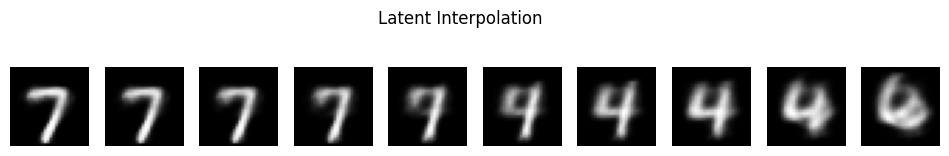

In [25]:
plt.figure(figsize=(12,2))
for i,img in enumerate(images):
    plt.subplot(1,10,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis("off")
plt.suptitle("Latent Interpolation")
plt.show()


📌 Explanation for report:
Interpolation is smooth because KL-divergence makes latent space continuous and Gaussian.

🟢 PART 2 — LATENT DISTRIBUTION ANALYSIS

In [26]:
zs = []

with torch.no_grad():
    for x,_ in test_loader:
        mu = model.mu(model.encoder(x))
        zs.append(mu)

z = torch.cat(zs).numpy()


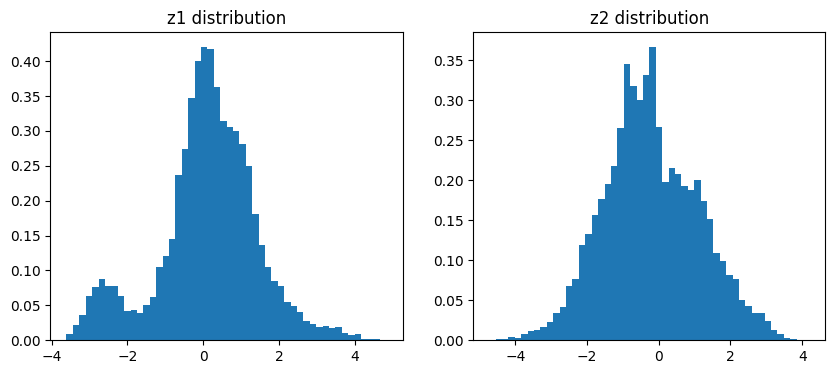

In [27]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(z[:,0], bins=50, density=True)
plt.title("z1 distribution")

plt.subplot(1,2,2)
plt.hist(z[:,1], bins=50, density=True)
plt.title("z2 distribution")

plt.show()


🔴 PART 3 — ANOMALY DETECTION USING VAE

Digits 9 = anomalies

Reconstruction error function

In [28]:
def reconstruction_error(x, x_hat):
    return F.binary_cross_entropy(
        x_hat, x.view(-1,784), reduction='none'
    ).sum(dim=1)


In [29]:
errors = []
labels = []

with torch.no_grad():
    for x,y in test_loader:
        x_hat,_,_ = model(x)
        err = reconstruction_error(x, x_hat)
        errors.append(err)
        labels.append(y)

errors = torch.cat(errors).numpy()
labels = torch.cat(labels).numpy()


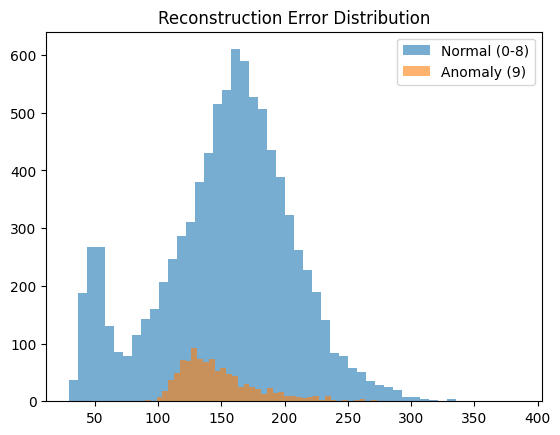

In [30]:
normal_err = errors[labels != 9]
anom_err   = errors[labels == 9]

plt.hist(normal_err, bins=50, alpha=0.6, label="Normal (0-8)")
plt.hist(anom_err, bins=50, alpha=0.6, label="Anomaly (9)")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()


In [31]:
threshold = normal_err.mean() + 3*normal_err.std()
print("Threshold:", threshold)


Threshold: 313.80408


In [32]:
pred_anomaly = errors > threshold
true_anomaly = labels == 9

accuracy = (pred_anomaly == true_anomaly).mean()
print("Anomaly detection accuracy:", accuracy)


Anomaly detection accuracy: 0.8983


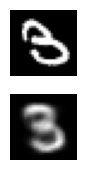

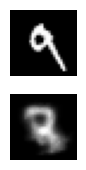

In [35]:
def show_reconstruction(digit):
    for x,y in test_loader:
        idx = (y==digit).nonzero()[0]
        # Only proceed if there are enough images of the digit to display
        if len(idx) > 0:
            x_filtered = x[idx]

            x_hat,_,_ = model(x_filtered) # Pass filtered x to the model

            plt.figure(figsize=(6,2))
            num_to_display = min(6, len(x_filtered))
            for i in range(num_to_display):
                plt.subplot(2,6,i+1)
                plt.imshow(x_filtered[i][0], cmap='gray')
                plt.axis("off")

                plt.subplot(2,6,i+7)
                plt.imshow(x_hat[i].detach().cpu().view(28,28), cmap='gray')
                plt.axis("off")
            plt.show()
            break # Break after the first batch with the digit found

show_reconstruction(3)  # normal
show_reconstruction(9)  # anomaly

Final explanation (for report)

Interpolation: shows continuity of latent space

Latent histogram: confirms KL makes q(z) ≈ N(0,1)

Anomaly detection: anomalies reconstructed poorly →high reconstruction loss